# Customer Churn Prediction Using Machine Learning

This notebook develops machine-learning models to predict customer churn using the DQLab Telco Final dataset.

The workflow is:

1. Exploratory Data Analysis (EDA)
2. Data preprocessing
3. Train/test splitting
4. Model training
5. Model evaluation
6. Model comparison and saving the selected model


## 1. Import Libraries

In [14]:
import os
import pickle
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

pd.set_option("display.max_columns", None)
sns.set_theme(style="whitegrid")


## 2. Load the Dataset

The notebook originally used `../../datasets/dqlab_telco_final.csv`. The loader below also checks common Kaggle and local locations so the notebook is easier to run in different environments.

In [15]:
def find_dataset(filename="dqlab_telco_final.csv"):
    candidates = [
        Path("../../datasets") / filename,
        Path("./datasets") / filename,
        Path(".") / filename,
        Path("/kaggle/input") / filename,
        Path("/mnt/data") / filename,
    ]

    for path in candidates:
        if path.is_file():
            return path

    kaggle_input = Path("/kaggle/input")
    if kaggle_input.exists():
        matches = list(kaggle_input.rglob(filename))
        if matches:
            return matches[0]

    raise FileNotFoundError(
        f"Could not find '{filename}'. "
        "Place the dataset in the notebook directory, a 'datasets' directory, "
        "or attach the DQLab Telco dataset in Kaggle."
    )


dataset_path = find_dataset()
print(f"Dataset path: {dataset_path}")

df_load = pd.read_csv(dataset_path)

print(f"Dataset shape: {df_load.shape}")
print("\nFirst 5 rows:")
display(df_load.head())

print(f"\nNumber of unique customer IDs: {df_load['customerID'].nunique()}")


Dataset path: ../../datasets/dqlab_telco_final.csv
Dataset shape: (6950, 13)

First 5 rows:


,UpdatedAt,customerID,gender,SeniorCitizen,Partner,tenure,PhoneService,StreamingTV,InternetService,PaperlessBilling,MonthlyCharges,TotalCharges,Churn
0,202006,45759018157,Female,No,Yes,1,No,No,Yes,Yes,29.85,29.85,No
1,202006,45315483266,Male,No,Yes,60,Yes,No,No,Yes,20.50,1198.80,No
2,202006,45236961615,Male,No,No,5,Yes,Yes,Yes,No,104.10,541.90,Yes
3,202006,45929827382,Female,No,Yes,72,Yes,Yes,Yes,Yes,115.50,8312.75,No
4,202006,45305082233,Female,No,Yes,56,Yes,Yes,Yes,No,81.25,4620.40,No



Number of unique customer IDs: 6950


## 3. Dataset Overview

In [16]:
print("Column names:")
print(df_load.columns.tolist())

print("\nData types:")
print(df_load.dtypes)

print("\nMissing values:")
print(df_load.isna().sum())

print("\nSummary statistics:")
display(df_load.describe(include="all").transpose())


Column names:
['UpdatedAt', 'customerID', 'gender', 'SeniorCitizen', 'Partner', 'tenure', 'PhoneService', 'StreamingTV', 'InternetService', 'PaperlessBilling', 'MonthlyCharges', 'TotalCharges', 'Churn']

Data types:
UpdatedAt             int64
customerID            int64
gender                  str
SeniorCitizen           str
Partner                 str
tenure                int64
PhoneService            str
StreamingTV             str
InternetService         str
PaperlessBilling        str
MonthlyCharges      float64
TotalCharges        float64
Churn                   str
dtype: object

Missing values:
UpdatedAt           0
customerID          0
gender              0
SeniorCitizen       0
Partner             0
tenure              0
PhoneService        0
StreamingTV         0
InternetService     0
PaperlessBilling    0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

Summary statistics:


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
UpdatedAt,6950.0,NaN,NaN,NaN,202006.0,0.0,202006.0,202006.0,202006.0,202006.0,202006.0
customerID,6950.0,NaN,NaN,NaN,45498975234.853096,285409137.04996,45000258625.0,45256067521.0,45498705615.5,45743844787.5,45999585058.0
gender,6950,2,Male,3505,NaN,NaN,NaN,NaN,NaN,NaN,NaN
SeniorCitizen,6950,2,No,5822,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Partner,6950,2,No,3591,NaN,NaN,NaN,NaN,NaN,NaN,NaN
tenure,6950.0,NaN,NaN,NaN,32.423165,24.581073,0.0,9.0,29.0,55.0,124.0
PhoneService,6950,2,Yes,6281,NaN,NaN,NaN,NaN,NaN,NaN,NaN
StreamingTV,6950,2,No,4279,NaN,NaN,NaN,NaN,NaN,NaN,NaN
InternetService,6950,2,Yes,5445,NaN,NaN,NaN,NaN,NaN,NaN,NaN
PaperlessBilling,6950,2,Yes,4114,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 4. Exploratory Data Analysis: Churn Distribution

Churn counts:
Churn
No     5114
Yes    1836
Name: count, dtype: int64

Churn percentages:
Churn
No     73.58
Yes    26.42
Name: proportion, dtype: float64


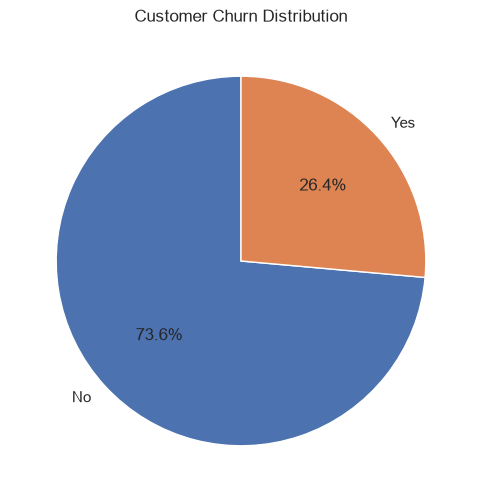

In [17]:
churn_counts = df_load["Churn"].value_counts()

print("Churn counts:")
print(churn_counts)

print("\nChurn percentages:")
print((df_load["Churn"].value_counts(normalize=True) * 100).round(2))

plt.figure(figsize=(6, 6))
plt.pie(
    churn_counts,
    labels=churn_counts.index,
    autopct="%.1f%%",
    startangle=90
)
plt.title("Customer Churn Distribution")
plt.show()


## 5. Exploratory Data Analysis: Numerical Variables

The original notebook examines `MonthlyCharges`, `TotalCharges`, and `tenure` for customers who churned and customers who did not.

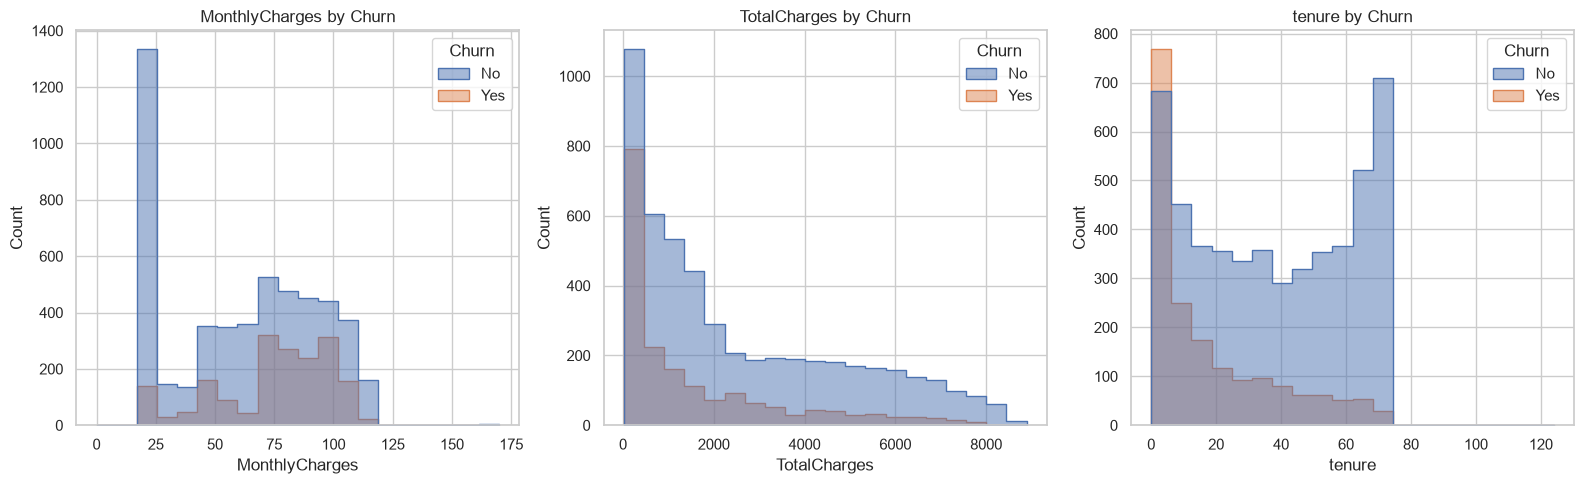

In [18]:
numerical_features = ["MonthlyCharges", "TotalCharges", "tenure"]

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for feature, ax in zip(numerical_features, axes):
    sns.histplot(
        data=df_load,
        x=feature,
        hue="Churn",
        bins=20,
        alpha=0.5,
        element="step",
        stat="count",
        ax=ax
    )
    ax.set_title(f"{feature} by Churn")

plt.tight_layout()
plt.show()


## 6. Exploratory Data Analysis: Categorical Variables

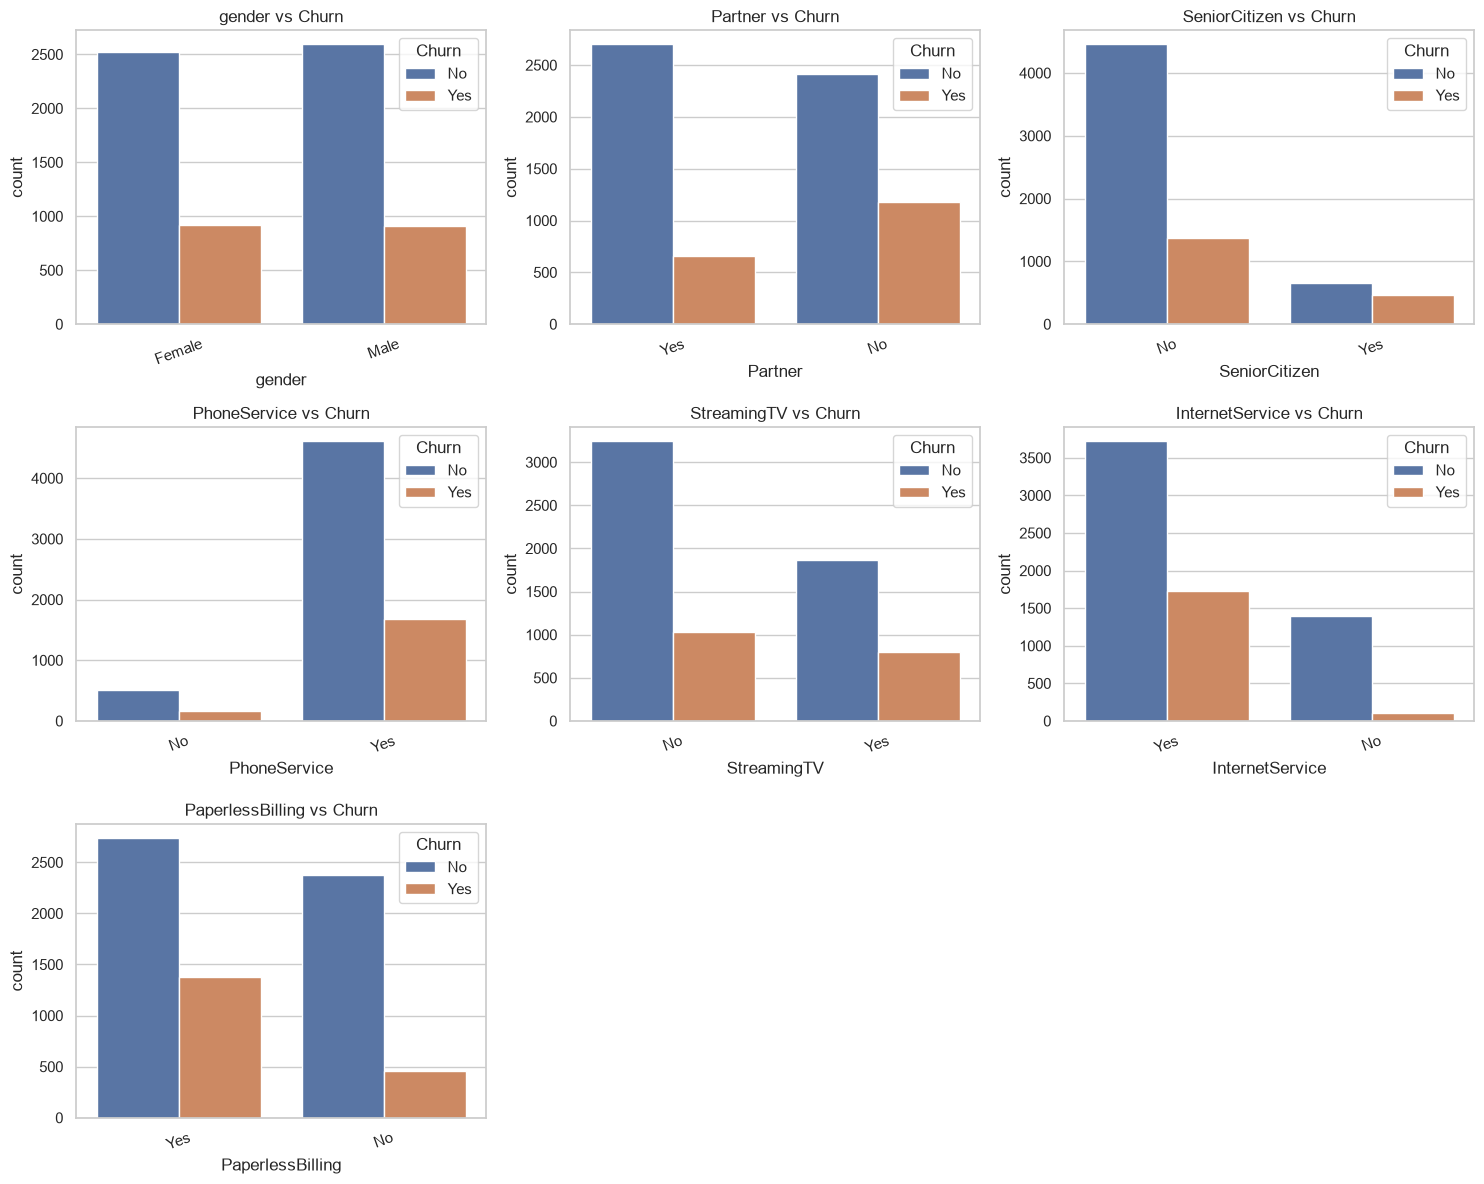

In [19]:
categorical_features = [
    "gender",
    "Partner",
    "SeniorCitizen",
    "PhoneService",
    "StreamingTV",
    "InternetService",
    "PaperlessBilling"
]

fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.flatten()

for ax, feature in zip(axes, categorical_features):
    sns.countplot(data=df_load, x=feature, hue="Churn", ax=ax)
    ax.set_title(f"{feature} vs Churn")
    ax.tick_params(axis="x", rotation=20)

for ax in axes[len(categorical_features):]:
    ax.remove()

plt.tight_layout()
plt.show()


## 7. EDA Summary

The original analysis reports that approximately 26% of customers churned and 74% did not churn. It also observes differences in churn patterns across monthly charges, tenure, partner status, senior-citizen status, streaming TV, internet service, and paperless billing.

These are descriptive observations from the dataset, not causal conclusions.

## 8. Remove Unnecessary Columns

`customerID` is an identifier rather than a predictive feature. `UpdatedAt` represents the data collection period and is also removed before modeling.

In [20]:
cleaned_df = df_load.drop(columns=["customerID", "UpdatedAt"]).copy()

print("Shape after removing unnecessary columns:", cleaned_df.shape)
display(cleaned_df.head())


Shape after removing unnecessary columns: (6950, 11)


,gender,SeniorCitizen,Partner,tenure,PhoneService,StreamingTV,InternetService,PaperlessBilling,MonthlyCharges,TotalCharges,Churn
0,Female,No,Yes,1,No,No,Yes,Yes,29.85,29.85,No
1,Male,No,Yes,60,Yes,No,No,Yes,20.50,1198.80,No
2,Male,No,No,5,Yes,Yes,Yes,No,104.10,541.90,Yes
3,Female,No,Yes,72,Yes,Yes,Yes,Yes,115.50,8312.75,No
4,Female,No,Yes,56,Yes,Yes,Yes,No,81.25,4620.40,No


## 9. Encode Categorical Variables

The original notebook uses `LabelEncoder` to convert non-numeric columns into numeric values.

The original loop contained an indentation/type-checking problem. The corrected version explicitly checks each column and encodes every non-numeric column.

In [34]:
from sklearn.preprocessing import LabelEncoder

label_encoders = {}

# Find all non-numeric columns
categorical_columns = cleaned_df.select_dtypes(
    exclude=["number"]
).columns

print("Categorical columns:", categorical_columns.tolist())

for column in categorical_columns:
    encoder = LabelEncoder()
    cleaned_df[column] = encoder.fit_transform(
        cleaned_df[column].astype(str)
    )
    label_encoders[column] = encoder

print("\nEncoded columns:", list(label_encoders.keys()))
print("\nData types after encoding:")
print(cleaned_df.dtypes)

Categorical columns: ['gender', 'SeniorCitizen', 'Partner', 'PhoneService', 'StreamingTV', 'InternetService', 'PaperlessBilling', 'Churn']

Encoded columns: ['gender', 'SeniorCitizen', 'Partner', 'PhoneService', 'StreamingTV', 'InternetService', 'PaperlessBilling', 'Churn']

Data types after encoding:
gender                int64
SeniorCitizen         int64
Partner               int64
tenure                int64
PhoneService          int64
StreamingTV           int64
InternetService       int64
PaperlessBilling      int64
MonthlyCharges      float64
TotalCharges        float64
Churn                 int64
dtype: object


## 10. Prepare Features and Target

In [35]:
X = cleaned_df.drop(columns=["Churn"])
y = cleaned_df["Churn"]

print(f"Feature matrix shape: {X.shape}")
print(f"Target shape: {y.shape}")

print("\nTarget distribution:")
print(y.value_counts(normalize=True).rename("proportion"))


Feature matrix shape: (6950, 10)
Target shape: (6950,)

Target distribution:
Churn
0    0.735827
1    0.264173
Name: proportion, dtype: float64


## 11. Split the Dataset

The original notebook uses a 70/30 train/test split with `random_state=42`.

In [36]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

print(f"Training features: {X_train.shape}")
print(f"Testing features: {X_test.shape}")
print(f"Training target: {y_train.shape}")
print(f"Testing target: {y_test.shape}")

print("\nChurn distribution in the training set:")
print(y_train.value_counts(normalize=True))


Training features: (4865, 10)
Testing features: (2085, 10)
Training target: (4865,)
Testing target: (2085,)

Churn distribution in the training set:
Churn
0    0.735868
1    0.264132
Name: proportion, dtype: float64


## 12. Logistic Regression

In [37]:
log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_train, y_train)

y_train_pred_log = log_model.predict(X_train)
y_test_pred_log = log_model.predict(X_test)

print("Logistic Regression model:")
print(log_model)


Logistic Regression model:
LogisticRegression(max_iter=1000)


## 13. Logistic Regression Evaluation

In [38]:
print("Logistic Regression — Training Classification Report")
print(classification_report(y_train, y_train_pred_log))

print("Logistic Regression — Testing Classification Report")
print(classification_report(y_test, y_test_pred_log))

log_train_accuracy = accuracy_score(y_train, y_train_pred_log)
log_test_accuracy = accuracy_score(y_test, y_test_pred_log)

print(f"Training accuracy: {log_train_accuracy:.2%}")
print(f"Testing accuracy:  {log_test_accuracy:.2%}")


Logistic Regression — Training Classification Report
              precision    recall  f1-score   support

           0       0.83      0.91      0.87      3580
           1       0.65      0.49      0.56      1285

    accuracy                           0.80      4865
   macro avg       0.74      0.70      0.71      4865
weighted avg       0.78      0.80      0.79      4865

Logistic Regression — Testing Classification Report
              precision    recall  f1-score   support

           0       0.83      0.90      0.87      1534
           1       0.64      0.50      0.56       551

    accuracy                           0.79      2085
   macro avg       0.74      0.70      0.71      2085
weighted avg       0.78      0.79      0.79      2085

Training accuracy: 79.61%
Testing accuracy:  79.47%


## 14. Logistic Regression Confusion Matrices

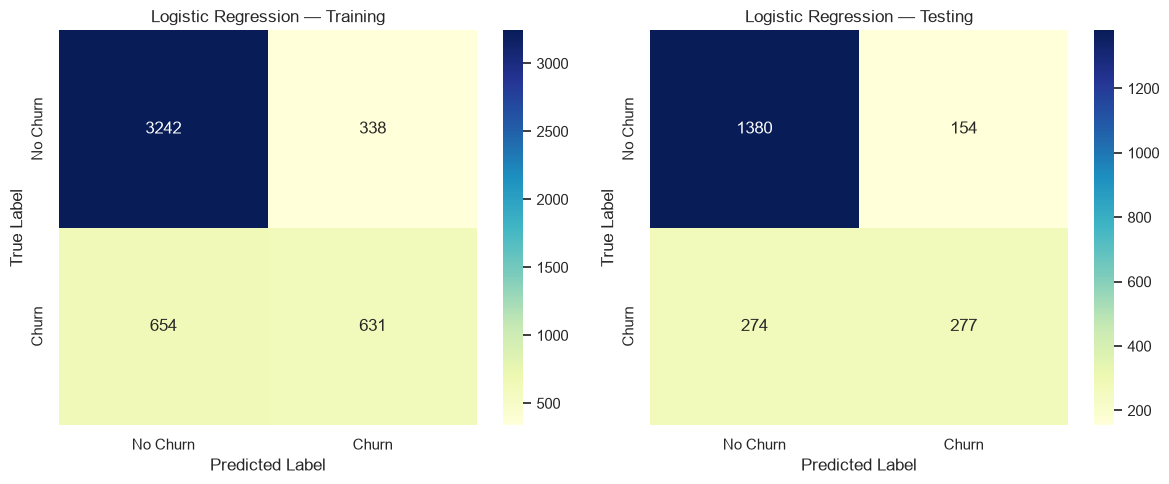

In [39]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, true_values, predictions, title in [
    (axes[0], y_train, y_train_pred_log, "Training"),
    (axes[1], y_test, y_test_pred_log, "Testing")
]:
    cm = confusion_matrix(true_values, predictions)
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="YlGnBu",
        xticklabels=["No Churn", "Churn"],
        yticklabels=["No Churn", "Churn"],
        ax=ax
    )
    ax.set_title(f"Logistic Regression — {title}")
    ax.set_xlabel("Predicted Label")
    ax.set_ylabel("True Label")

plt.tight_layout()
plt.show()


## 15. Random Forest Classifier

The original notebook mentions Random Forest in the model-selection discussion but does not actually train it. The corrected notebook includes it so the comparison is complete.

In [40]:
rf_model = RandomForestClassifier(
    n_estimators=300,
    random_state=42
)
rf_model.fit(X_train, y_train)

y_train_pred_rf = rf_model.predict(X_train)
y_test_pred_rf = rf_model.predict(X_test)

rf_train_accuracy = accuracy_score(y_train, y_train_pred_rf)
rf_test_accuracy = accuracy_score(y_test, y_test_pred_rf)

print("Random Forest — Training accuracy:", f"{rf_train_accuracy:.2%}")
print("Random Forest — Testing accuracy: ", f"{rf_test_accuracy:.2%}")

print("\nRandom Forest — Testing Classification Report")
print(classification_report(y_test, y_test_pred_rf))


Random Forest — Training accuracy: 99.75%
Random Forest — Testing accuracy:  76.35%

Random Forest — Testing Classification Report
              precision    recall  f1-score   support

           0       0.82      0.87      0.84      1534
           1       0.56      0.48      0.52       551

    accuracy                           0.76      2085
   macro avg       0.69      0.67      0.68      2085
weighted avg       0.75      0.76      0.76      2085



## 16. Gradient Boosting Classifier

The original notebook's section titled "Random Forest Classifier" actually trains a `GradientBoostingClassifier`. The heading is corrected here so it matches the code.

In [41]:
gbt_model = GradientBoostingClassifier(random_state=42)
gbt_model.fit(X_train, y_train)

y_train_pred_gbt = gbt_model.predict(X_train)
y_test_pred_gbt = gbt_model.predict(X_test)

gbt_train_accuracy = accuracy_score(y_train, y_train_pred_gbt)
gbt_test_accuracy = accuracy_score(y_test, y_test_pred_gbt)

print("Gradient Boosting — Training accuracy:", f"{gbt_train_accuracy:.2%}")
print("Gradient Boosting — Testing accuracy: ", f"{gbt_test_accuracy:.2%}")

print("\nGradient Boosting — Testing Classification Report")
print(classification_report(y_test, y_test_pred_gbt))


Gradient Boosting — Training accuracy: 82.14%
Gradient Boosting — Testing accuracy:  79.28%

Gradient Boosting — Testing Classification Report
              precision    recall  f1-score   support

           0       0.83      0.90      0.86      1534
           1       0.64      0.49      0.55       551

    accuracy                           0.79      2085
   macro avg       0.74      0.70      0.71      2085
weighted avg       0.78      0.79      0.78      2085



## 17. Model Comparison

In [43]:
results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest",
        "Gradient Boosting"
    ],
    "Training Accuracy": [
        log_train_accuracy,
        rf_train_accuracy,
        gbt_train_accuracy
    ],
    "Testing Accuracy": [
        log_test_accuracy,
        rf_test_accuracy,
        gbt_test_accuracy
    ]
})

results["Generalization Gap"] = (
    results["Training Accuracy"] - results["Testing Accuracy"]
)

results = results.sort_values("Testing Accuracy", ascending=False).reset_index(drop=True)

display(
    results.style.format({
        "Training Accuracy": "{:.2%}",
        "Testing Accuracy": "{:.2%}",
        "Generalization Gap": "{:.2%}"
    })
)


,Model,Training Accuracy,Testing Accuracy,Generalization Gap
0,Logistic Regression,79.61%,79.47%,0.14%
1,Gradient Boosting,82.14%,79.28%,2.86%
2,Random Forest,99.75%,76.35%,23.40%


## 18. Select and Save the Model

The original notebook selected Logistic Regression because it reported approximately 80% training accuracy and 79% testing accuracy and described the training/testing performance as relatively consistent.

The corrected notebook also prints the measured comparison above so the selection can be checked against the current run.

In [44]:
# Preserve the original notebook's selected model.
best_model = log_model

model_path = Path("best_model_churn.pkl")
with model_path.open("wb") as file:
    pickle.dump(best_model, file)

print(f"Selected model: {type(best_model).__name__}")
print(f"Model saved to: {model_path.resolve()}")
print(f"Training accuracy: {log_train_accuracy:.2%}")
print(f"Testing accuracy:  {log_test_accuracy:.2%}")


Selected model: LogisticRegression
Model saved to: /Users/yusufaxmad/Documents/ai/learning/ML-learning/courseworks/notebooks/best_model_churn.pkl
Training accuracy: 79.61%
Testing accuracy:  79.47%


## 19. Final Conclusion

The notebook builds a complete customer-churn prediction workflow:

- Customer identifiers and collection-date information are removed.
- Categorical variables are converted to numeric values.
- The dataset is divided into training and testing sets.
- Logistic Regression, Random Forest, and Gradient Boosting are evaluated.
- The original project selects Logistic Regression as the final model.
- The trained model is saved as `best_model_churn.pkl`.

Model performance should be interpreted using the current execution results rather than relying only on previously reported percentages.

## Source

Based on the Kaggle notebook:

**Customer Churn Prediction using Machine Learning — samran98**

Dataset: **DQLab Telco Final**

All notebook messages and result labels in this corrected version are written in English.
